In [1]:
import os
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
import torchvision.models as models

from torchvision.models import (
    ResNet18_Weights,
    VGG16_Weights
)

In [2]:
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Using Device: {DEVICE}")


Using Device: cpu


In [4]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [5]:
NUM_CLASSES = 10
RESNET_MODEL_PATH = "/content/drive/MyDrive/final project/saved_models/resnet18_fashionmnist.pth"

VGG_MODEL_PATH = "/content/drive/MyDrive/final project/saved_models/vgg16_fashionmnist.pth"


In [6]:
# LOAD RESNET18 MODEL
# =========================================================
resnet_model = models.resnet18(
    weights=ResNet18_Weights.IMAGENET1K_V1
)

# MODIFY FINAL LAYER
resnet_model.fc = nn.Linear(
    resnet_model.fc.in_features,
    NUM_CLASSES
)

# LOAD SAVED WEIGHTS
resnet_model.load_state_dict(
    torch.load(
        RESNET_MODEL_PATH,
        map_location=DEVICE
    )
)

resnet_model = resnet_model.to(DEVICE)

print("\nResNet18 Model Loaded Successfully")


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 85.7MB/s]



ResNet18 Model Loaded Successfully


In [7]:
# LOAD VGG16 MODEL
# =========================================================
vgg_model = models.vgg16(
    weights=VGG16_Weights.IMAGENET1K_V1
)

# MODIFY FINAL LAYER
vgg_model.classifier[6] = nn.Linear(
    vgg_model.classifier[6].in_features,
    NUM_CLASSES
)

# LOAD SAVED WEIGHTS
vgg_model.load_state_dict(
    torch.load(
        VGG_MODEL_PATH,
        map_location=DEVICE
    )
)

vgg_model = vgg_model.to(DEVICE)

print("VGG16 Model Loaded Successfully")

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 146MB/s]


VGG16 Model Loaded Successfully


In [8]:
# MODEL PARAMETERS COMPARISON
# =========================================================
resnet_params = sum(
    p.numel() for p in resnet_model.parameters()
)

vgg_params = sum(
    p.numel() for p in vgg_model.parameters()
)

In [9]:
# CREATE COMPARISON TABLE
# =========================================================
comparison_df = pd.DataFrame({

    "Model": [
        "ResNet18",
        "VGG16"
    ],

    "Total Parameters": [
        resnet_params,
        vgg_params
    ]
})

print("\nModel Comparison Table\n")
print(comparison_df)


Model Comparison Table

      Model  Total Parameters
0  ResNet18          11181642
1     VGG16         134301514


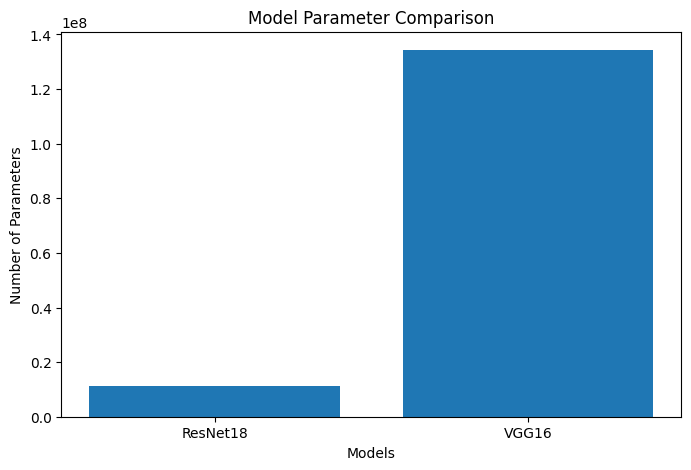

In [10]:
# PARAMETER COMPARISON GRAPH
# =========================================================
plt.figure(figsize=(8,5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Total Parameters"]
)

plt.title("Model Parameter Comparison")
plt.xlabel("Models")
plt.ylabel("Number of Parameters")

plt.show()


In [11]:
# MODEL SIZE COMPARISON
# =========================================================
resnet_size = os.path.getsize(
    RESNET_MODEL_PATH
) / (1024 * 1024)

vgg_size = os.path.getsize(
    VGG_MODEL_PATH
) / (1024 * 1024)

size_df = pd.DataFrame({

    "Model": [
        "ResNet18",
        "VGG16"
    ],

    "Model Size (MB)": [
        round(resnet_size, 2),
        round(vgg_size, 2)
    ]
})

print("\nModel Size Comparison\n")
print(size_df)


Model Size Comparison

      Model  Model Size (MB)
0  ResNet18            42.73
1     VGG16           512.33


In [12]:
# FINAL ANALYSIS
# =========================================================
print("\nFinal Comparison Analysis\n")

if resnet_params < vgg_params:

    print("ResNet18 is lighter and more efficient.")

else:

    print("VGG16 is lighter and more efficient.")

print(f"\nResNet18 Parameters : {resnet_params:,}")
print(f"VGG16 Parameters    : {vgg_params:,}")

print(f"\nResNet18 Size : {resnet_size:.2f} MB")
print(f"VGG16 Size    : {vgg_size:.2f} MB")


Final Comparison Analysis

ResNet18 is lighter and more efficient.

ResNet18 Parameters : 11,181,642
VGG16 Parameters    : 134,301,514

ResNet18 Size : 42.73 MB
VGG16 Size    : 512.33 MB
